## Project Setup & Data Access

In [ ]:
# Install necessary libraries if not already present in Colab
!pip install pandas numpy statsmodels matplotlib seaborn yfinance scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from io import StringIO
from sklearn.model_selection import train_test_split # Not directly used for time series split, but good to have
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.genmod import families # Not explicitly used, but sometimes part of statsmodels import patterns

In [ ]:
# dowland the Fama-French data from the data library
import requests
import zipfile
import io

# URL of the zip file
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"

# Download the zip file
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Create a ZipFile object from the content
    with zipfile.ZipFile(io.BytesIO(response.content)) as thezip:
        # Assuming there's only one CSV file in the zip archive,
        # otherwise you might need to loop through the file list.
        # Get the name of the first file in the zip archive
        zip_info = thezip.infolist()[0]
        csv_filename = zip_info.filename

        # Read the CSV file into a pandas DataFrame
        with thezip.open(csv_filename) as data_file:
            # You might need to adjust the skiprows parameter based on the file's structure
            # to skip any initial descriptive text.
            # After inspecting the file, it seems there are 3 initial rows to skip.
            df_raw = pd.read_csv(data_file, skiprows=3)

            # Display the first few rows of the DataFrame
            print(df_raw.head())

            # Now you can work with your DataFrame 'df'
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

  Unnamed: 0  Mkt-RF   SMB   HML   RMW   CMA     RF
0   19630701   -0.67  0.00 -0.34 -0.01  0.16  0.012
1   19630702    0.79 -0.26  0.26 -0.07 -0.20  0.012
2   19630703    0.63 -0.17 -0.09  0.18 -0.34  0.012
3   19630705    0.40  0.08 -0.27  0.09 -0.34  0.012
4   19630708   -0.63  0.04 -0.18 -0.29  0.14  0.012


In [ ]:
ff_data_string_example = """
This file was created by using the 202505 CRSP database.
The 1-month TBill return is from Ibbotson and Associates, Inc.

,Mkt-RF,SMB,HML,RMW,CMA,RF
19630701,   -0.67,    0.00,   -0.34,   -0.01,    0.16,   0.012
19630702,    0.79,   -0.26,    0.26,   -0.07,   -0.20,   0.012
19630703,    0.63,   -0.17,   -0.09,    0.18,   -0.34,   0.012
""" # Only a small part for StringIO example.

#ff_factors = pd.read_csv(StringIO(ff_data_string_example), skiprows=3, index_col=0)

ff_factors = df_raw.copy()
ff_factors.columns = ["Date", "Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]
ff_factors = ff_factors[ff_factors["Date"].str.isnumeric()]

# Convert index to datetime
ff_factors["Date"] = pd.to_datetime(ff_factors["Date"], format="%Y%m%d")
ff_factors = ff_factors.set_index("Date")

# Data Cleaning and Preparation
# Remove any rows with non-numeric values (e.g., ' -99.99' or comments at the end of the file)
ff_factors = ff_factors.apply(pd.to_numeric, errors='coerce').dropna()

# Convert factor returns from percentage to decimal
#ff_factors = ff_factors / 100.0

print("Fama-French Factors Data Head (after cleaning):")
print(ff_factors.head())
print("\nFama-French Factors Data Info (after cleaning):")
ff_factors.info()

Fama-French Factors Data Head (after cleaning):
            Mkt-RF   SMB   HML   RMW   CMA     RF
Date                                             
1963-07-01   -0.67  0.00 -0.34 -0.01  0.16  0.012
1963-07-02    0.79 -0.26  0.26 -0.07 -0.20  0.012
1963-07-03    0.63 -0.17 -0.09  0.18 -0.34  0.012
1963-07-05    0.40  0.08 -0.27  0.09 -0.34  0.012
1963-07-08   -0.63  0.04 -0.18 -0.29  0.14  0.012

Fama-French Factors Data Info (after cleaning):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15583 entries, 1963-07-01 to 2025-05-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  15583 non-null  float64
 1   SMB     15583 non-null  float64
 2   HML     15583 non-null  float64
 3   RMW     15583 non-null  float64
 4   CMA     15583 non-null  float64
 5   RF      15583 non-null  float64
dtypes: float64(6)
memory usage: 852.2 KB


In [ ]:
# Define a 3-year period for analysis
start_date = '2020-01-01'
end_date = '2022-12-31'
ff_factors_period = ff_factors[(ff_factors.index >= start_date) & (ff_factors.index <= end_date)]

print(f"\nData successfully loaded and filtered for {start_date} to {end_date}.")
print(f"Number of observations in selected period: {len(ff_factors_period)}")


Data successfully loaded and filtered for 2020-01-01 to 2022-12-31.
Number of observations in selected period: 756


In [ ]:
ff_factors_period.tail()

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2022-12-23,0.52,-0.35,1.16,0.86,0.53,0.016
2022-12-27,-0.50,-0.42,1.42,1.15,1.35,0.016
2022-12-28,-1.24,-0.30,-0.28,-0.93,-0.08,0.016
2022-12-29,1.87,1.02,-1.06,-1.03,-0.90,0.016
2022-12-30,-0.22,0.14,-0.04,-0.54,-0.02,0.016


##Step 2: Fama-French Data Exploration and Correlation Analysis


--- Step 2: Fama-French Data Analysis (2020-01-01 to 2022-12-31) ---

2.a. Plotting Daily Factor Returns:


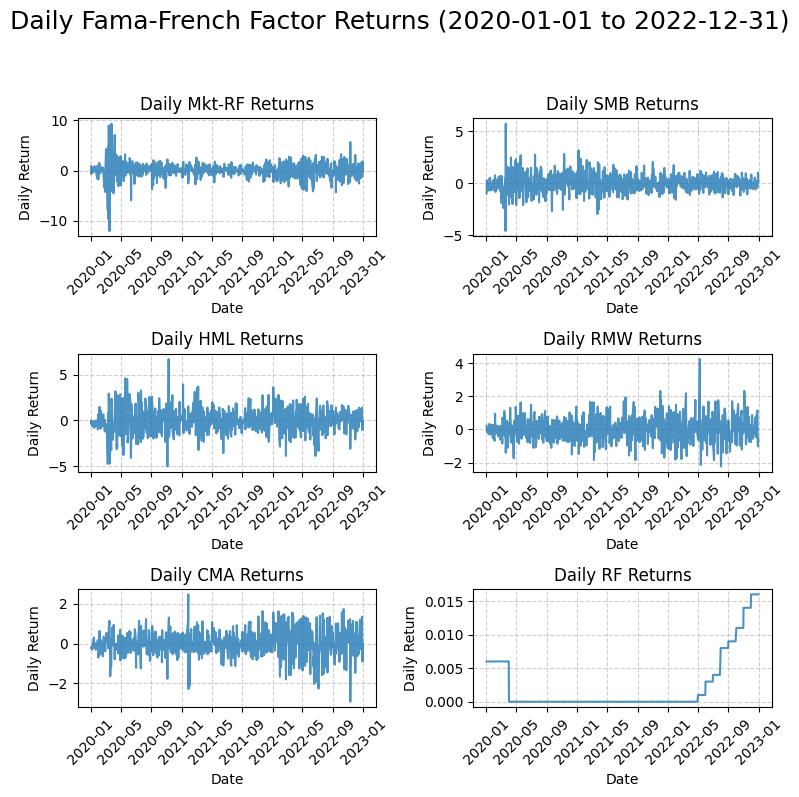


2.b. Correlation Matrix of Fama-French Factors:
        Mkt-RF     SMB     HML     RMW     CMA
Mkt-RF  1.0000  0.1996 -0.0424 -0.1354 -0.2929
SMB     0.1996  1.0000  0.3318 -0.2290 -0.0014
HML    -0.0424  0.3318  1.0000  0.4552  0.6485
RMW    -0.1354 -0.2290  0.4552  1.0000  0.4324
CMA    -0.2929 -0.0014  0.6485  0.4324  1.0000


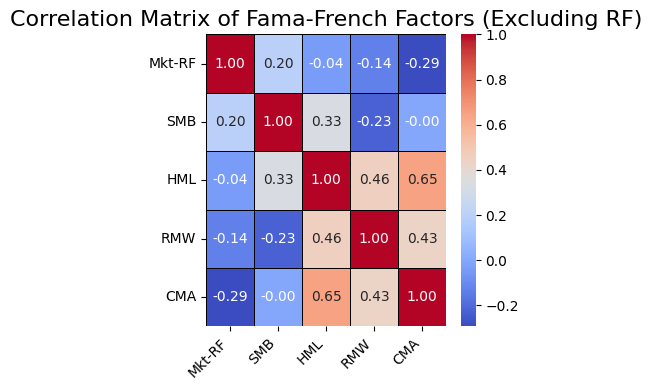

In [ ]:
# --- Step 2: Fama-French Data Analysis ---

print(f"\n--- Step 2: Fama-French Data Analysis ({start_date} to {end_date}) ---")

# 2.a. Plot Daily Factor Returns
print("\n2.a. Plotting Daily Factor Returns:")
plt.figure(figsize=(8, 8))
for i, col in enumerate(ff_factors_period.columns):
    plt.subplot(3, 2, i + 1) # Create 3 rows, 2 columns of subplots
    plt.plot(ff_factors_period.index, ff_factors_period[col], label=col, alpha=0.8)
    plt.title(f'Daily {col} Returns')
    plt.xlabel('Date')
    plt.ylabel('Daily Return')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
plt.suptitle(f'Daily Fama-French Factor Returns ({start_date} to {end_date})', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# 2.b. Correlation Matrix of Fama-French Factors
print("\n2.b. Correlation Matrix of Fama-French Factors:")
correlation_matrix = ff_factors_period.drop(columns=['RF']).corr() # Exclude RF for correlation as it's risk-free
print(correlation_matrix.round(4))

plt.figure(figsize=(4, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Correlation Matrix of Fama-French Factors (Excluding RF)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# 2.c. Incorporate Economic Data
import pandas_datareader.data as web
import datetime

# 10-Year Treasury Yield
treasury_10y = web.DataReader('GS10', 'fred', start_date, end_date)

# Consumer Price Index (CPI)
cpi = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)

# Federal Funds Rate
fed_rate = web.DataReader('FEDFUNDS', 'fred', start_date, end_date)

# Unemployment Rate
unemployment = web.DataReader('UNRATE', 'fred', start_date, end_date)

# VIX (Volatility Index)
vix = web.DataReader('VIXCLS', 'fred', start_date, end_date)


In [ ]:
econ_data = pd.concat([treasury_10y, cpi, fed_rate, unemployment, vix], axis=1)
econ_data.columns = ['10Y_Treasury', 'CPI', 'Fed_Funds_Rate', 'Unemployment', 'VIX']
econ_data.dropna(inplace=True)
econ_data.head()

,10Y_Treasury,CPI,Fed_Funds_Rate,Unemployment,VIX
DATE,,,,,
2020-04-01,0.66,256.032,0.05,14.8,57.06
2020-05-01,0.67,255.802,0.05,13.2,37.19
2020-06-01,0.73,257.042,0.08,11.0,28.23
2020-07-01,0.62,258.352,0.09,10.2,28.62
2020-09-01,0.68,259.997,0.09,7.8,26.12



2.c. Plotting Economic Data:


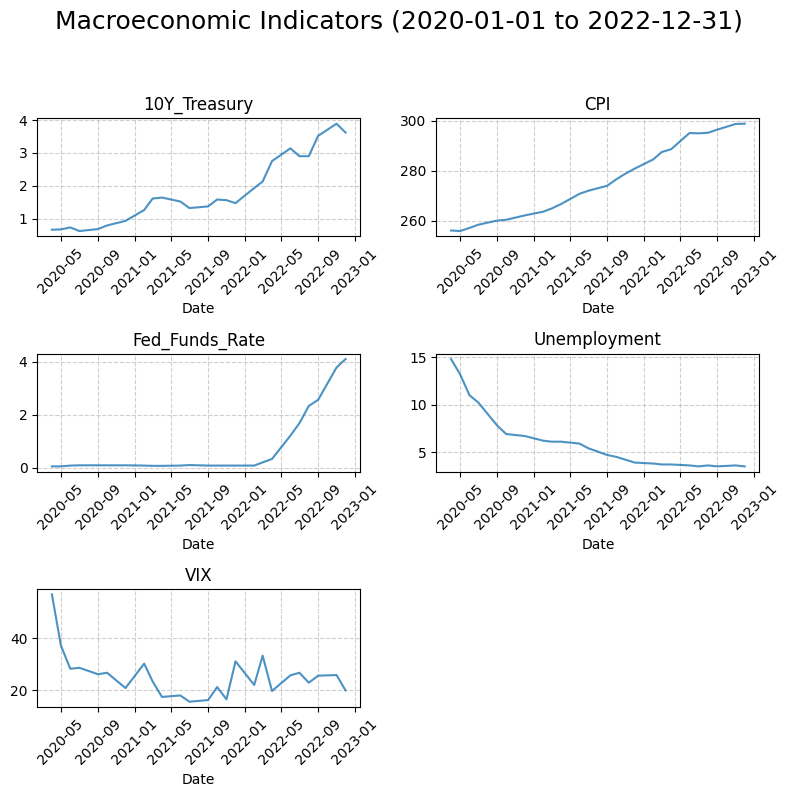

In [ ]:
print("\n2.c. Plotting Economic Data:")
plt.figure(figsize=(8, 8))
for i, col in enumerate(econ_data.columns):
    plt.subplot(3, 2, i + 1) # Create 3 rows, 2 columns of subplots
    plt.plot(econ_data.index, econ_data[col], label=col, alpha=0.8)
    plt.title(f'{col}')
    plt.xlabel('Date')

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
plt.suptitle(f' Macroeconomic Indicators ({start_date} to {end_date})', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

## Step 3: Fama-French 3-Factor (FF3) Model Regression

In [ ]:
# --- Step 3: Fama-French 3-Factor Model ---

print("\n--- Step 3: Fama-French 3-Factor Model ---")

# 3.a. Acquire Sample Stock Data (e.g., Apple Inc. - AAPL)
# For demonstration, we'll use AAPL stock. You can change this to any other stock.
STOCK_TICKER = 'AAPL'
print(f"\n3.a. Downloading daily adjusted close prices for {STOCK_TICKER} from {start_date} to {end_date}...")
try:
    stock_data = yf.download(STOCK_TICKER, start=start_date, end=end_date, progress=False) # Added progress=False to reduce verbose output
    stock_data['Daily_Return'] = stock_data['Close'].pct_change()
    stock_returns = stock_data['Daily_Return'].dropna()

    # Align stock data with Fama-French factors
    # Use 'inner' join to ensure only dates present in BOTH datasets are kept.
    # This is crucial for matching daily returns with daily factor data.
    merged_data = pd.merge(stock_returns.rename(f'{STOCK_TICKER}_Return'), ff_factors_period,
                           left_index=True, right_index=True, how='inner')

    # Calculate Excess Return for the stock
    # Ensure 'RF' column exists in merged_data before subtraction
    if 'RF' in merged_data.columns:
        merged_data[f'{STOCK_TICKER}_Excess_Return'] = merged_data[f'{STOCK_TICKER}_Return'] - merged_data['RF']
    else:
        raise ValueError("'RF' (Risk-Free Rate) column not found in Fama-French data. Please check data loading.")

    # Drop rows with any NaN values that might result from merging or calculations
    # This is a good final check before regression
    merged_data.dropna(inplace=True)

    if merged_data.empty:
        raise ValueError("Merged data is empty after aligning stock returns and Fama-French factors. Check date ranges or data availability.")


    print(f"\nMerged Data for {STOCK_TICKER} and Fama-French Factors Head:")
    print(merged_data.head())
    print(f"\nMerged Data for {STOCK_TICKER} and Fama-French Factors Info:")
    merged_data.info()

except Exception as e:
    print(f"Error downloading or processing {STOCK_TICKER} data: {e}")
    print("Please ensure you have an active internet connection, check the stock ticker symbol, or verify the specified date range.")
    print("Also, confirm that 'ff_factors_period' and 'start_date'/'end_date' variables are correctly defined from previous steps.")
    # It's better to raise the error or exit here if critical data loading fails,
    # as subsequent steps will depend on 'merged_data'
    raise # Re-raise the exception to stop execution if data is missing

# Define dependent and independent variables for FF3
# Ensure the columns exist in merged_data
required_cols_ff3 = [f'{STOCK_TICKER}_Excess_Return', 'Mkt-RF', 'SMB', 'HML']
if not all(col in merged_data.columns for col in required_cols_ff3):
    raise ValueError(f"Missing one or more required columns for FF3 regression in merged_data: {required_cols_ff3}. Check previous steps.")

y_ff3 = merged_data[f'{STOCK_TICKER}_Excess_Return']
X_ff3 = merged_data[['Mkt-RF', 'SMB', 'HML']]
X_ff3 = sm.add_constant(X_ff3) # Add constant for the intercept (alpha)

# 3.c. Train-Test Split (Time-Series)
train_size_ratio = 0.8
split_point = int(len(X_ff3) * train_size_ratio)

# Ensure split_point results in non-empty train and test sets
if split_point == 0 or split_point == len(X_ff3):
    raise ValueError("Train/test split resulted in an empty training or testing set. Adjust date range or train_size_ratio.")

X_train_ff3, X_test_ff3 = X_ff3.iloc[:split_point], X_ff3.iloc[split_point:]
y_train_ff3, y_test_ff3 = y_ff3.iloc[:split_point], y_ff3.iloc[split_point:]

print(f"\nData split: Total samples {len(X_ff3)}. Training samples: {len(X_train_ff3)}, Testing samples: {len(X_test_ff3)}.")
print(f"FF3 Training Period: {X_train_ff3.index.min().strftime('%Y-%m-%d')} to {X_train_ff3.index.max().strftime('%Y-%m-%d')}")
print(f"FF3 Testing Period: {X_test_ff3.index.min().strftime('%Y-%m-%d')} to {X_test_ff3.index.max().strftime('%Y-%m-%d')}")

# 3.d. Model Estimation (OLS and Robust Regression)

# OLS Regression for FF3
print("\n--- FF3: OLS Regression Results (Training Data) ---")
try:
    ff3_ols_model = sm.OLS(y_train_ff3, X_train_ff3)
    ff3_ols_results = ff3_ols_model.fit()
    print(ff3_ols_results.summary())
except Exception as e:
    print(f"Error during FF3 OLS regression: {e}")
    print("This might be due to perfect multicollinearity or very few data points. Check X_train_ff3.")
    raise

# Robust (Huber) Regression for FF3
print("\n--- FF3: Robust (Huber) Regression Results (Training Data) ---")
try:
    ff3_robust_model = sm.RLM(y_train_ff3, X_train_ff3, M=sm.robust.norms.HuberT())
    ff3_robust_results = ff3_robust_model.fit()
    print(ff3_robust_results.summary())
except Exception as e:
    print(f"Error during FF3 Robust regression: {e}")
    print("This might be due to perfect multicollinearity or very few data points. Check X_train_ff3.")
    raise

# 3.e. Model Evaluation for FF3
print("\n--- FF3: Model Evaluation on Training and Testing Data ---")

# OLS Predictions and Metrics
y_pred_ols_ff3_train = ff3_ols_results.predict(X_train_ff3)
mse_ols_ff3_train = mean_squared_error(y_train_ff3, y_pred_ols_ff3_train)
mae_ols_ff3_train = mean_absolute_error(y_train_ff3, y_pred_ols_ff3_train)
r2_ols_ff3_train = r2_score(y_train_ff3, y_pred_ols_ff3_train)

# Ensure X_test_ff3 has the same columns as X_train_ff3 for prediction
if not X_test_ff3.empty:
    y_pred_ols_ff3_test = ff3_ols_results.predict(X_test_ff3)
    mse_ols_ff3_test = mean_squared_error(y_test_ff3, y_pred_ols_ff3_test)
    mae_ols_ff3_test = mean_absolute_error(y_test_ff3, y_pred_ols_ff3_test)
    r2_ols_ff3_test = r2_score(y_test_ff3, y_pred_ols_ff3_test)


else:
    mse_ols_ff3_test = np.nan
    mae_ols_ff3_test = np.nan
    r2_ols_ff3_test = np.nan
    print("Warning: Test set for FF3 OLS is empty, skipping test evaluation.")


print(f"FF3 OLS Train MSE: {mse_ols_ff3_train:.8f}, MAE: {mae_ols_ff3_train:.8f}")
print(f"FF3 OLS Test MSE: {mse_ols_ff3_test:.8f}, MAE: {mae_ols_ff3_test:.8f}")

# Robust Predictions and Metrics
y_pred_robust_ff3_train = ff3_robust_results.predict(X_train_ff3)
mse_robust_ff3_train = mean_squared_error(y_train_ff3, y_pred_robust_ff3_train)
mae_robust_ff3_train = mean_absolute_error(y_train_ff3, y_pred_robust_ff3_train)

if not X_test_ff3.empty:
    y_pred_robust_ff3_test = ff3_robust_results.predict(X_test_ff3)
    mse_robust_ff3_test = mean_squared_error(y_test_ff3, y_pred_robust_ff3_test)
    mae_robust_ff3_test = mean_absolute_error(y_test_ff3, y_pred_robust_ff3_test)
else:
    mse_robust_ff3_test = np.nan
    mae_robust_ff3_test = np.nan
    print("Warning: Test set for FF3 Robust is empty, skipping test evaluation.")

print(f"FF3 Robust Train MSE: {mse_robust_ff3_train:.8f}, MAE: {mae_robust_ff3_train:.8f}")
print(f"FF3 Robust Test MSE: {mse_robust_ff3_test:.8f}, MAE: {mae_robust_ff3_test:.8f}")
print(f"FF3 OLS Train R-squared: {r2_ols_ff3_train:.8f}")
print(f"FF3 OLS Test R-squared: {r2_ols_ff3_test:.8f}")


--- Step 3: Fama-French 3-Factor Model ---

3.a. Downloading daily adjusted close prices for AAPL from 2020-01-01 to 2022-12-31...


/tmp/ipython-input-11-3351487007.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(STOCK_TICKER, start=start_date, end=end_date, progress=False) # Added progress=False to reduce verbose output



Merged Data for AAPL and Fama-French Factors Head:
            AAPL_Return  Mkt-RF   SMB   HML   RMW   CMA     RF  \
Date                                                             
2020-01-03    -0.009722   -0.67  0.29  0.01 -0.14 -0.17  0.006   
2020-01-06     0.007969    0.36 -0.22 -0.55 -0.16 -0.31  0.006   
2020-01-07    -0.004703   -0.19 -0.04 -0.26 -0.13 -0.31  0.006   
2020-01-08     0.016086    0.47 -0.18 -0.64 -0.21 -0.15  0.006   
2020-01-09     0.021241    0.65 -0.71 -0.48 -0.15  0.07  0.006   

            AAPL_Excess_Return  
Date                            
2020-01-03           -0.015722  
2020-01-06            0.001969  
2020-01-07           -0.010703  
2020-01-08            0.010086  
2020-01-09            0.015241  

Merged Data for AAPL and Fama-French Factors Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 755 entries, 2020-01-03 to 2022-12-30
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              -----

##Step 4: Fama-French 5-Factor (FF5) Model Regression

In [ ]:
# --- Step 4: Fama-French 5-Factor Model ---

print("\n--- Step 4: Fama-French 5-Factor Model ---")

# Define dependent and independent variables for FF5
# Use the same 'merged_data' from Step 3 for consistency
y_ff5 = merged_data[f'{STOCK_TICKER}_Excess_Return']
X_ff5 = merged_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
X_ff5 = sm.add_constant(X_ff5) # Add constant for the intercept (alpha)

# Train-Test Split (Time-Series) for FF5 (using the same split point from Step 3)
X_train_ff5, X_test_ff5 = X_ff5.iloc[:split_point], X_ff5.iloc[split_point:]
y_train_ff5, y_test_ff5 = y_ff5.iloc[:split_point], y_ff5.iloc[split_point:]

print(f"\nFF5 Training Period: {X_train_ff5.index.min().strftime('%Y-%m-%d')} to {X_train_ff5.index.max().strftime('%Y-%m-%d')}")
print(f"FF5 Testing Period: {X_test_ff5.index.min().strftime('%Y-%m-%d')} to {X_test_ff5.index.max().strftime('%Y-%m-%d')}")
print(f"Train samples: {len(X_train_ff5)}, Test samples: {len(X_test_ff5)}")

# OLS Regression for FF5
print("\n--- FF5: OLS Regression Results (Training Data) ---")
ff5_ols_model = sm.OLS(y_train_ff5, X_train_ff5)
ff5_ols_results = ff5_ols_model.fit()
print(ff5_ols_results.summary())

# Robust (Huber) Regression for FF5
print("\n--- FF5: Robust (Huber) Regression Results (Training Data) ---")
ff5_robust_model = sm.RLM(y_train_ff5, X_train_ff5, M=sm.robust.norms.HuberT())
ff5_robust_results = ff5_robust_model.fit()
print(ff5_robust_results.summary())

# Model Evaluation for FF5
print("\n--- FF5: Model Evaluation on Training and Testing Data ---")

# OLS Predictions and Metrics
y_pred_ols_ff5_train = ff5_ols_results.predict(X_train_ff5)
mse_ols_ff5_train = mean_squared_error(y_train_ff5, y_pred_ols_ff5_train)
mae_ols_ff5_train = mean_absolute_error(y_train_ff5, y_pred_ols_ff5_train)
r2_ols_ff5_train = r2_score(y_train_ff5, y_pred_ols_ff5_train)

y_pred_ols_ff5_test = ff5_ols_results.predict(X_test_ff5)
mse_ols_ff5_test = mean_squared_error(y_test_ff5, y_pred_ols_ff5_test)
mae_ols_ff5_test = mean_absolute_error(y_test_ff5, y_pred_ols_ff5_test)
r2_ols_ff5_test = r2_score(y_test_ff5, y_pred_ols_ff5_test)

print(f"FF5 OLS Train MSE: {mse_ols_ff5_train:.8f}, MAE: {mae_ols_ff5_train:.8f}")
print(f"FF5 OLS Test MSE: {mse_ols_ff5_test:.8f}, MAE: {mae_ols_ff5_test:.8f}")

# Robust Predictions and Metrics
y_pred_robust_ff5_train = ff5_robust_results.predict(X_train_ff5)
mse_robust_ff5_train = mean_squared_error(y_train_ff5, y_pred_robust_ff5_train)
mae_robust_ff5_train = mean_absolute_error(y_train_ff5, y_pred_robust_ff5_train)

y_pred_robust_ff5_test = ff5_robust_results.predict(X_test_ff5)
mse_robust_ff5_test = mean_squared_error(y_test_ff5, y_pred_robust_ff5_test)
mae_robust_ff5_test = mean_absolute_error(y_test_ff5, y_pred_robust_ff5_test)

print(f"FF5 Robust Train MSE: {mse_robust_ff5_train:.8f}, MAE: {mae_robust_ff5_train:.8f}")
print(f"FF5 Robust Test MSE: {mse_robust_ff5_test:.8f}, MAE: {mae_robust_ff5_test:.8f}")
print(f"FF5 OLS Train R-squared: {r2_ols_ff5_train:.8f}") # Added
print(f"FF5 OLS Test R-squared: {r2_ols_ff5_test:.8f}")   # Added


--- Step 4: Fama-French 5-Factor Model ---

FF5 Training Period: 2020-01-03 to 2022-05-25
FF5 Testing Period: 2022-05-26 to 2022-12-30
Train samples: 604, Test samples: 151

--- FF5: OLS Regression Results (Training Data) ---
                            OLS Regression Results                            
Dep. Variable:     AAPL_Excess_Return   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     496.1
Date:                Thu, 24 Jul 2025   Prob (F-statistic):          4.63e-210
Time:                        16:08:16   Log-Likelihood:                 1902.4
No. Observations:                 604   AIC:                            -3793.
Df Residuals:                     598   BIC:                            -3766.
Df Model:                           5                                         
Covariance Type:            nonrobust                         

##Step 5: Analyzing Factor Relationships


--- Step 5: Analyzing Factor Relationships (Full 3-Year Period) ---

5.a. Correlation Matrix of Fama-French (5) Factors:
        Mkt-RF     SMB     HML     RMW     CMA
Mkt-RF  1.0000  0.1996 -0.0424 -0.1354 -0.2929
SMB     0.1996  1.0000  0.3318 -0.2290 -0.0014
HML    -0.0424  0.3318  1.0000  0.4552  0.6485
RMW    -0.1354 -0.2290  0.4552  1.0000  0.4324
CMA    -0.2929 -0.0014  0.6485  0.4324  1.0000


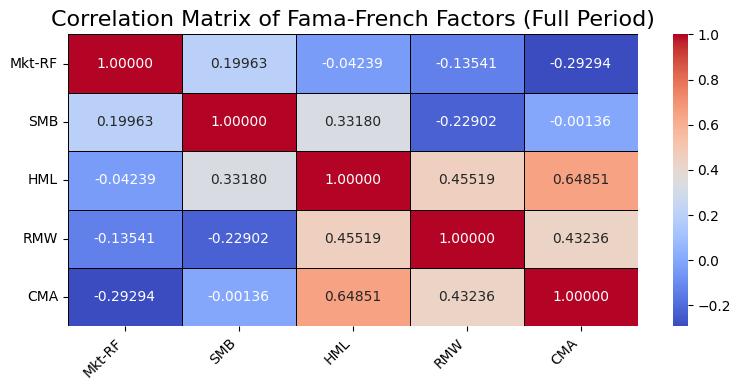


5.b. Covariance Matrix of Fama-French (5) Factors:
          Mkt-RF       SMB       HML       RMW       CMA
Mkt-RF  2.684931  0.283809 -0.093836 -0.162988 -0.310934
SMB     0.283809  0.752770  0.388871 -0.145964 -0.000763
HML    -0.093836  0.388871  1.824703  0.451683  0.567471
RMW    -0.162988 -0.145964  0.451683  0.539626  0.205741
CMA    -0.310934 -0.000763  0.567471  0.205741  0.419619


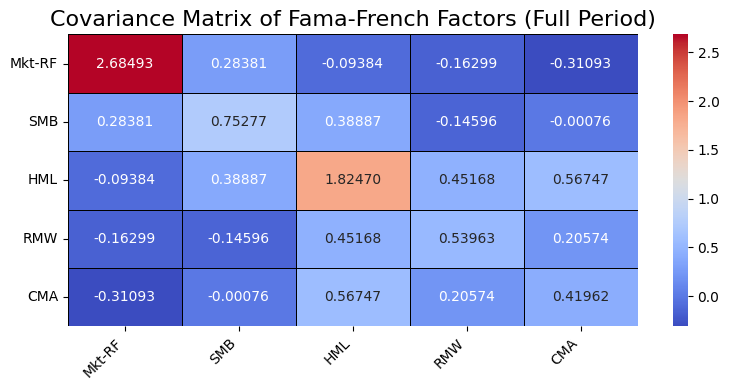

In [ ]:
# --- Step 5: Analyzing Factor Relationships ---

print("\n--- Step 5: Analyzing Factor Relationships (Full 3-Year Period) ---")

# For this step, we'll use the Fama-French factors within the selected 3-year period
# Exclude RF as it's a risk-free rate, not a risk factor for correlation/covariance with other factors.
factors_for_analysis = ff_factors_period[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]

# Correlation Matrix
print("\n5.a. Correlation Matrix of Fama-French (5) Factors:")
correlation_matrix_full = factors_for_analysis.corr()
print(correlation_matrix_full.round(4))

plt.figure(figsize=(8, 4))
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', fmt=".5f", linewidths=.5, linecolor='black')
plt.title('Correlation Matrix of Fama-French Factors (Full Period)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Covariance Matrix
print("\n5.b. Covariance Matrix of Fama-French (5) Factors:")
covariance_matrix_full = factors_for_analysis.cov()
print(covariance_matrix_full.round(8)) # Show more decimals as values can be very small

plt.figure(figsize=(8,4 ))
sns.heatmap(covariance_matrix_full, annot=True, cmap='coolwarm', fmt=".5f", linewidths=.5, linecolor='black')
plt.title('Covariance Matrix of Fama-French Factors (Full Period)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


##Step 6: Tabular Comparison of Model Results

In [ ]:
# --- Step 6: Tabular Comparison of Model Results ---

print("\n--- Step 6: Tabular Comparison of Model Results ---")

# Function to safely extract a parameter or 'N/A'
def get_param(results, param_name):
    return results.params.get(param_name, np.nan)

# Function to safely extract a p-value or 'N/A'
def get_pvalue(results, param_name):
    return results.pvalues.get(param_name, np.nan)

# Function to safely extract R-squared, handling different model types
def get_rsquared(results):
    if hasattr(results, 'rsquared'):
        return results.rsquared
    elif hasattr(results, 'prsquared'): # Use pseudo R-squared for robust models
        return results.prsquared
    else:
        return np.nan

# Function to safely extract Adjusted R-squared, handling different model types
def get_adj_rsquared(results):
    if hasattr(results, 'rsquared_adj'):
        return results.rsquared_adj
    # Robust models generally don't have a direct adjusted pseudo R-squared equivalent
    else:
        return np.nan


# Create a dictionary to store all relevant metrics
results_data = []

# FF3 OLS Training
results_data.append({
    'Model': 'FF3 OLS',
    'Alpha (const)': get_param(ff3_ols_results, 'const'),
    'Mkt-RF': get_param(ff3_ols_results, 'Mkt-RF'),
    'SMB': get_param(ff3_ols_results, 'SMB'),
    'HML': get_param(ff3_ols_results, 'HML'),
    'RMW': np.nan, # Not in FF3
    'CMA': np.nan, # Not in FF3
    'Alpha p-value': get_pvalue(ff3_ols_results, 'const'),
    'Mkt-RF p-value': get_pvalue(ff3_ols_results, 'Mkt-RF'),
    'SMB p-value': get_pvalue(ff3_ols_results, 'SMB'),
    'HML p-value': get_pvalue(ff3_ols_results, 'HML'),
    'RMW p-value': np.nan,
    'CMA p-value': np.nan,
    'Train R-squared (or Pseudo)': get_rsquared(ff3_ols_results),
    'Test R-squared (or Pseudo)': r2_ols_ff3_test,
    'Adjusted R-squared': get_adj_rsquared(ff3_ols_results),
    'Train MSE': mse_ols_ff3_train,
    'Test MSE': mse_ols_ff3_test,
    'Train MAE': mae_ols_ff3_train,
    'Test MAE': mae_ols_ff3_test
})

# FF3 Robust Training
results_data.append({
    'Model': 'FF3 Robust',
    'Alpha (const)': get_param(ff3_robust_results, 'const'),
    'Mkt-RF': get_param(ff3_robust_results, 'Mkt-RF'),
    'SMB': get_param(ff3_robust_results, 'SMB'),
    'HML': get_param(ff3_robust_results, 'HML'),
    'RMW': np.nan,
    'CMA': np.nan,
    'Alpha p-value': get_pvalue(ff3_robust_results, 'const'),
    'Mkt-RF p-value': get_pvalue(ff3_robust_results, 'Mkt-RF'),
    'SMB p-value': get_pvalue(ff3_robust_results, 'SMB'),
    'HML p-value': get_pvalue(ff3_robust_results, 'HML'),
    'RMW p-value': np.nan,
    'CMA p-value': np.nan,
    'Train R-squared (or Pseudo)': get_rsquared(ff3_robust_results),
    'Test R-squared (or Pseudo)': np.nan,
    'Adjusted R-squared': get_adj_rsquared(ff3_robust_results),
    'Train MSE': mse_robust_ff3_train,
    'Test MSE': mse_robust_ff3_test,
    'Train MAE': mae_robust_ff3_train,
    'Test MAE': mae_robust_ff3_test
})

# FF5 OLS Training
results_data.append({
    'Model': 'FF5 OLS',
    'Alpha (const)': get_param(ff5_ols_results, 'const'),
    'Mkt-RF': get_param(ff5_ols_results, 'Mkt-RF'),
    'SMB': get_param(ff5_ols_results, 'SMB'),
    'HML': get_param(ff5_ols_results, 'HML'),
    'RMW': get_param(ff5_ols_results, 'RMW'),
    'CMA': get_param(ff5_ols_results, 'CMA'),
    'Alpha p-value': get_pvalue(ff5_ols_results, 'const'),
    'Mkt-RF p-value': get_pvalue(ff5_ols_results, 'Mkt-RF'),
    'SMB p-value': get_pvalue(ff5_ols_results, 'SMB'),
    'HML p-value': get_pvalue(ff5_ols_results, 'HML'),
    'RMW p-value': get_pvalue(ff5_ols_results, 'RMW'),
    'CMA p-value': get_pvalue(ff5_ols_results, 'CMA'),
    'Train R-squared (or Pseudo)': get_rsquared(ff5_ols_results),
    'Test R-squared (or Pseudo)': r2_ols_ff5_test,
    'Adjusted R-squared': get_adj_rsquared(ff5_ols_results),
    'Train MSE': mse_ols_ff5_train,
    'Test MSE': mse_ols_ff5_test,
    'Train MAE': mae_ols_ff5_train,
    'Test MAE': mae_ols_ff5_test
})

# FF5 Robust Training
results_data.append({
    'Model': 'FF5 Robust',
    'Alpha (const)': get_param(ff5_robust_results, 'const'),
    'Mkt-RF': get_param(ff5_robust_results, 'Mkt-RF'),
    'SMB': get_param(ff5_robust_results, 'SMB'),
    'HML': get_param(ff5_robust_results, 'HML'),
    'RMW': get_param(ff5_robust_results, 'RMW'),
    'CMA': get_param(ff5_robust_results, 'CMA'),
    'Alpha p-value': get_pvalue(ff5_robust_results, 'const'),
    'Mkt-RF p-value': get_pvalue(ff5_robust_results, 'Mkt-RF'),
    'SMB p-value': get_pvalue(ff5_robust_results, 'SMB'),
    'HML p-value': get_pvalue(ff5_robust_results, 'HML'),
    'RMW p-value': get_pvalue(ff5_robust_results, 'RMW'),
    'CMA p-value': get_pvalue(ff5_robust_results, 'CMA'),
    'Train R-squared (or Pseudo)': get_rsquared(ff5_robust_results),
    'Test R-squared (or Pseudo)': np.nan,
    'Adjusted R-squared': get_adj_rsquared(ff5_robust_results),
    'Train MSE': mse_robust_ff5_train,
    'Test MSE': mse_robust_ff5_test,
    'Train MAE': mae_robust_ff5_train,
    'Test MAE': mae_robust_ff5_test
})


summary_df = pd.DataFrame(results_data)
# Set 'Model' as index for cleaner display, then transpose to have models as columns
summary_df.set_index('Model', inplace=True)
summary_df_transposed = summary_df.transpose()

print(summary_df_transposed.to_string(float_format="%.6f"))


--- Step 6: Tabular Comparison of Model Results ---
Model                         FF3 OLS  FF3 Robust   FF5 OLS  FF5 Robust
Alpha (const)                0.000208   -0.000063 -0.000416   -0.000478
Mkt-RF                       0.012095    0.012071  0.013087    0.013178
SMB                         -0.004495   -0.004066 -0.001657   -0.001401
HML                         -0.002656   -0.002482 -0.007871   -0.007608
RMW                               NaN         NaN  0.004404    0.004322
CMA                               NaN         NaN  0.013177    0.012442
Alpha p-value                0.676251    0.884387  0.329691    0.192665
Mkt-RF p-value               0.000000    0.000000  0.000000    0.000000
SMB p-value                  0.000000    0.000000  0.003787    0.004291
HML p-value                  0.000000    0.000000  0.000000    0.000000
RMW p-value                       NaN         NaN  0.000000    0.000000
CMA p-value                       NaN         NaN  0.000000    0.000000
Train R-squ

## Step 7: Portfolio Optimization and Fama-French Analysis of the Optimized Portfolio


--- Step 7: Portfolio Optimization and Fama-French Analysis of the Optimized Portfolio ---

7.a. Downloading daily adjusted close prices for portfolio tickers (AAPL, MSFT, JPM, XOM, JNJ) from 2020-01-01 to 2022-12-31...


/tmp/ipython-input-15-2722878116.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  portfolio_data = yf.download(PORTFOLIO_TICKERS, start=start_date, end=end_date, progress=False)['Close']



Portfolio Daily Returns Head:
Ticker          AAPL       JNJ       JPM      MSFT       XOM
Date                                                        
2020-01-03 -0.009722 -0.011578 -0.013197 -0.012452 -0.008039
2020-01-06  0.007969 -0.001247 -0.000795  0.002585  0.007678
2020-01-07 -0.004703  0.006107 -0.017000 -0.009118 -0.008184
2020-01-08  0.016086 -0.000138  0.007801  0.015928 -0.015080
2020-01-09  0.021241  0.002966  0.003651  0.012493  0.007656

Portfolio Daily Returns Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 755 entries, 2020-01-03 to 2022-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    755 non-null    float64
 1   JNJ     755 non-null    float64
 2   JPM     755 non-null    float64
 3   MSFT    755 non-null    float64
 4   XOM     755 non-null    float64
dtypes: float64(5)
memory usage: 35.4 KB

Starting Portfolio Optimization (Monte Carlo Simulation)...

Portfolio Optimization Com

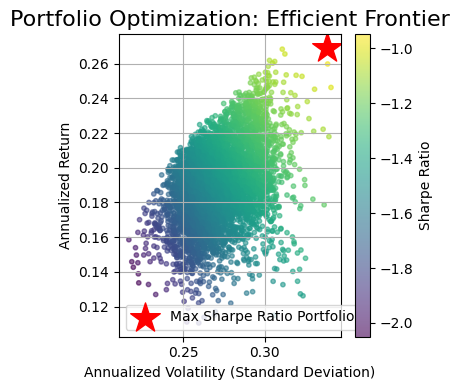


Optimized Portfolio Daily Returns Head:
Date
2020-01-03   -0.008734
2020-01-06    0.007097
2020-01-07   -0.007416
2020-01-08   -0.007166
2020-01-09    0.010142
dtype: float64

Merged Optimized Portfolio Data with Fama-French Factors Head:
            Optimized_Portfolio_Return  Mkt-RF   SMB   HML   RMW   CMA     RF  \
Date                                                                            
2020-01-03                   -0.008734   -0.67  0.29  0.01 -0.14 -0.17  0.006   
2020-01-06                    0.007097    0.36 -0.22 -0.55 -0.16 -0.31  0.006   
2020-01-07                   -0.007416   -0.19 -0.04 -0.26 -0.13 -0.31  0.006   
2020-01-08                   -0.007166    0.47 -0.18 -0.64 -0.21 -0.15  0.006   
2020-01-09                    0.010142    0.65 -0.71 -0.48 -0.15  0.07  0.006   

            Optimized_Portfolio_Excess_Return  
Date                                           
2020-01-03                          -0.014734  
2020-01-06                           0.001097  


In [ ]:
# --- Step 7: Portfolio Optimization and Fama-French Analysis of the Optimized Portfolio ---

print("\n--- Step 7: Portfolio Optimization and Fama-French Analysis of the Optimized Portfolio ---")

# 7.a. Select 5 Tickers and Download Data
PORTFOLIO_TICKERS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']
print(f"\n7.a. Downloading daily adjusted close prices for portfolio tickers ({', '.join(PORTFOLIO_TICKERS)}) from {start_date} to {end_date}...")

portfolio_data = yf.download(PORTFOLIO_TICKERS, start=start_date, end=end_date, progress=False)['Close']

# Calculate daily returns for the portfolio
portfolio_returns = portfolio_data.pct_change().dropna()

print("\nPortfolio Daily Returns Head:")
print(portfolio_returns.head())
print("\nPortfolio Daily Returns Info:")
portfolio_returns.info()

# 7.b. Portfolio Optimization (Maximizing Sharpe Ratio)
# This is a simplified Monte Carlo simulation for demonstration.

num_portfolios = 5000 # Number of random portfolios to generate
results = np.zeros((3 + len(PORTFOLIO_TICKERS), num_portfolios)) # For returns, volatility, sharpe, and weights

mean_daily_returns = portfolio_returns.mean()
cov_matrix = portfolio_returns.cov()
annual_risk_free_rate = ff_factors_period['RF'].mean() * 252 # Annualize daily RF rate

print("\nStarting Portfolio Optimization (Monte Carlo Simulation)...")

for i in range(num_portfolios):
    weights = np.random.random(len(PORTFOLIO_TICKERS))
    weights /= np.sum(weights) # Normalize weights to sum to 1

    portfolio_return = np.sum(mean_daily_returns * weights) * 252 # Annualized return
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252) # Annualized volatility

    sharpe_ratio = (portfolio_return - annual_risk_free_rate) / portfolio_std_dev

    results[0, i] = portfolio_return
    results[1, i] = portfolio_std_dev
    results[2, i] = sharpe_ratio
    for j in range(len(weights)):
        results[j+3, i] = weights[j]

results_df = pd.DataFrame(results.T, columns=['Return', 'Volatility', 'Sharpe Ratio'] + [ticker + '_Weight' for ticker in PORTFOLIO_TICKERS])

# Find the portfolio with the maximum Sharpe Ratio
max_sharpe_portfolio = results_df.loc[results_df['Sharpe Ratio'].idxmax()]

print("\nPortfolio Optimization Complete.")
print("Optimal Portfolio (Max Sharpe Ratio):")
print(f"  Annualized Return: {max_sharpe_portfolio['Return']:.4f}")
print(f"  Annualized Volatility: {max_sharpe_portfolio['Volatility']:.4f}")
print(f"  Sharpe Ratio: {max_sharpe_portfolio['Sharpe Ratio']:.4f}")
print("  Optimal Weights:")
for ticker in PORTFOLIO_TICKERS:
    print(f"    {ticker}: {max_sharpe_portfolio[ticker + '_Weight']:.4f}")

# Plotting the efficient frontier
plt.figure(figsize=(4, 4))
plt.scatter(results_df['Volatility'], results_df['Return'], c=results_df['Sharpe Ratio'], cmap='viridis', marker='o', s=10, alpha=0.6)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(max_sharpe_portfolio['Volatility'], max_sharpe_portfolio['Return'], marker='*', color='red', s=500, label='Max Sharpe Ratio Portfolio')
plt.title('Portfolio Optimization: Efficient Frontier', fontsize=16)
plt.xlabel('Annualized Volatility (Standard Deviation)')
plt.ylabel('Annualized Return')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 7.c. Calculate Optimized Portfolio's Daily Returns
optimal_weights = np.array([max_sharpe_portfolio[ticker + '_Weight'] for ticker in PORTFOLIO_TICKERS])
optimized_portfolio_daily_returns = (portfolio_returns * optimal_weights).sum(axis=1)

print("\nOptimized Portfolio Daily Returns Head:")
print(optimized_portfolio_daily_returns.head())

# 7.d. Merge Optimized Portfolio Returns with Fama-French Factors
# Align the optimized portfolio returns with Fama-French factors and RF rate
merged_optimized_portfolio_data = pd.merge(
    optimized_portfolio_daily_returns.rename('Optimized_Portfolio_Return'),
    ff_factors_period,
    left_index=True,
    right_index=True,
    how='inner'
).dropna()

# Calculate Excess Return for the optimized portfolio
merged_optimized_portfolio_data['Optimized_Portfolio_Excess_Return'] = \
    merged_optimized_portfolio_data['Optimized_Portfolio_Return'] - merged_optimized_portfolio_data['RF']

print("\nMerged Optimized Portfolio Data with Fama-French Factors Head:")
print(merged_optimized_portfolio_data.head())
print("\nMerged Optimized Portfolio Data Info:")
merged_optimized_portfolio_data.info()

# 7.e. Perform FF3 and FF5 Regressions on the Optimized Portfolio's Excess Returns

# Prepare data for regressions
y_optimized = merged_optimized_portfolio_data['Optimized_Portfolio_Excess_Return']

# Use the same train-test split logic (e.g., 80/20 time-series split)
split_point_opt = int(len(y_optimized) * train_size_ratio)

y_train_opt, y_test_opt = y_optimized.iloc[:split_point_opt], y_optimized.iloc[split_point_opt:]

# FF3 Regression for Optimized Portfolio
X_ff3_opt = merged_optimized_portfolio_data[['Mkt-RF', 'SMB', 'HML']]
X_ff3_opt = sm.add_constant(X_ff3_opt)
X_train_ff3_opt, X_test_ff3_opt = X_ff3_opt.iloc[:split_point_opt], X_ff3_opt.iloc[split_point_opt:]

print("\n--- FF3 Regression for Optimized Portfolio (OLS) ---")
ff3_opt_ols_model = sm.OLS(y_train_opt, X_train_ff3_opt).fit()
print(ff3_opt_ols_model.summary())

print("\n--- FF3 Regression for Optimized Portfolio (Robust) ---")
ff3_opt_robust_model = sm.RLM(y_train_opt, X_train_ff3_opt, M=sm.robust.norms.HuberT()).fit()
print(ff3_opt_robust_model.summary())

# FF5 Regression for Optimized Portfolio
X_ff5_opt = merged_optimized_portfolio_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
X_ff5_opt = sm.add_constant(X_ff5_opt)
X_train_ff5_opt, X_test_ff5_opt = X_ff5_opt.iloc[:split_point_opt], X_ff5_opt.iloc[split_point_opt:]

print("\n--- FF5 Regression for Optimized Portfolio (OLS) ---")
ff5_opt_ols_model = sm.OLS(y_train_opt, X_train_ff5_opt).fit()
print(ff5_opt_ols_model.summary())

print("\n--- FF5 Regression for Optimized Portfolio (Robust) ---")
ff5_opt_robust_model = sm.RLM(y_train_opt, X_train_ff5_opt, M=sm.robust.norms.HuberT()).fit()
print(ff5_opt_robust_model.summary())

print("\n--- Step 7 Complete ---")
print("The code has performed portfolio optimization and run FF3/FF5 regressions on the optimized portfolio.")
print("You can now analyze the output summaries to understand the factor exposures of your optimized portfolio.")